# voice enabled ai assistant

In [1]:
%pip install -q torch transformers datasets accelerate soundfile librosa matplotlib sentencepiece protobuf sounddevice

# Explanation of each library:
# - torch: PyTorch, a popular deep learning framework.
# - transformers: Hugging Face Transformers, a library for natural language processing and deep learning models.
# - datasets: Hugging Face Datasets, a library for easily accessing and sharing datasets.
# - accelerate: Hugging Face Accelerate, a library for easy distributed training and inference.
# - soundfile: A library for reading and writing sound files.
# - librosa: A library for audio and music analysis.
# - matplotlib: A plotting library for creating static, animated, and interactive visualizations in Python.
# - sentencepiece: A library for unsupervised text tokenization and detokenization.
# - protobuf: A library for serializing structured data, used in many machine learning frameworks.
# - sounddevice: A library for playing and recording audio in Python.

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 1 - Verify critical dependencies for SpeechT5
# checking required modules are imported or not
import importlib

required = ["sentencepiece", "soundfile", "accelerate", "transformers", "datasets", "sounddevice"]
missing = []

for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"[OK] {pkg}")
    except Exception:
        missing.append(pkg)
        print(f"[MISSING] {pkg}")

if missing:
    print("\nInstall missing packages with:")
    print(f"%pip install {' '.join(missing)}")
    print("Then restart kernel and rerun from Step 2.")
else:
    print("\nAll critical dependencies are available.")


[OK] sentencepiece
[OK] soundfile


c:\coding\python\deep_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] accelerate
[OK] transformers
[OK] datasets
[OK] sounddevice

All critical dependencies are available.


In [3]:
# Step 2 - Imports and environment setup

import io
import numpy as np
import torch
import matplotlib.pyplot as plt
import soundfile as sf

from accelerate import Accelerator
from transformers import (
    pipeline,
    AutoModelForSpeechSeq2Seq,
    AutoProcessor,
)
from datasets import load_dataset, Audio as HFAudio
from IPython.display import Audio, display

try:
    from transformers import SpeechT5HifiGan
except Exception:
    SpeechT5HifiGan = None

In [4]:
# Step 3 - Initialize Accelerator

accelerator = Accelerator()
device = accelerator.device

print(f"Accelerate selected device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")


Accelerate selected device: cuda
CUDA available: True


In [5]:
# varient of whisper link =   https://huggingface.co/openai/whisper-tiny

In [ ]:
# Step 4 - Voice assistant implementation

class VoiceAIAssistant:
    # Beginner-friendly voice assistant pipeline:
    
    # audio -> ASR -> text response -> TTS audio.

    def __init__(self, accelerator, use_llm=False):
        self.accelerator = accelerator
        self.device = accelerator.device
        self.device_index = 0 if self.device.type == "cuda" else -1
        self.use_llm = use_llm

        print("Loading ASR model (Whisper tiny) without pipeline codec dependency...")
        self.asr_model_id = "openai/whisper-tiny"
        self.asr_processor = AutoProcessor.from_pretrained(self.asr_model_id)
        self.asr_model = AutoModelForSpeechSeq2Seq.from_pretrained(self.asr_model_id)
        self.asr_model.to(self.device)
        self.asr_model.eval()

        # TTS setup with compatibility fallback across transformers versions.
        self.tts_backend = None
        self.speaker_embedding = None

        print("Loading TTS model (SpeechT5 + HiFi-GAN)...")
        try:
            if SpeechT5HifiGan is None:
                raise ImportError("SpeechT5HifiGan class is unavailable in this transformers build.")

            vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")
            self.tts = pipeline(
                "text-to-speech",
                model="microsoft/speecht5_tts",
                vocoder=vocoder,
                device=self.device_index,
            )

            # SpeechT5 needs a speaker embedding vector to choose voice characteristics.
            emb_ds = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
            self.speaker_embedding = torch.tensor(emb_ds[7306]["xvector"], dtype=torch.float32).unsqueeze(0)
            self.speaker_embedding = self.speaker_embedding.to(self.device)
            self.tts_backend = "speecht5"
            print("SpeechT5 TTS loaded successfully.")

        except Exception as e:
            msg = str(e).lower()
            if "sentencepiece" in msg:
                print("SpeechT5 needs sentencepiece. Falling back to MMS-TTS to keep notebook runnable.")
            else:
                print(f"SpeechT5 load issue: {e}")

            # Fallback model with integrated vocoder (simpler and robust for teaching demos).
            print("Loading fallback TTS model: facebook/mms-tts-eng...")
            self.tts = pipeline(
                "text-to-speech",
                model="facebook/mms-tts-eng",
                device=self.device_index,
            )
            self.tts_backend = "mms"
            print("Fallback MMS-TTS loaded successfully.")

        self.llm = None
        if self.use_llm:
            # Optional extension: small LLM generation.
            try:
                self.llm = pipeline("text-generation", model="gpt2", device=self.device_index)
            except Exception as e:
                print(f"Could not load optional LLM: {e}")
                self.use_llm = False

        print(f"VoiceAIAssistant initialized (tts_backend={self.tts_backend}).")

    def _get_response(self, text):
        if self.use_llm and self.llm is not None:
            out = self.llm(f"User: {text}\nAssistant:", max_new_tokens=30, do_sample=True)
            generated = out[0]["generated_text"]
            return generated.split("Assistant:")[-1].strip()

        # Rule-based fallback for teaching and deterministic behavior.
        text_lower = text.lower()

        if "hello" in text_lower or "hi" in text_lower:
            return "Hello! Nice to hear from you. How can I help today?"
        if "time" in text_lower:
            from datetime import datetime
            return f"The current time is {datetime.now().strftime('%H:%M')}."
        if "thank" in text_lower:
            return "You are welcome. Happy to help."

        return (
            f"I heard: {text}. "
            "I am a basic voice assistant. You can say hello, ask for time, or say thank you."
        )

    def process_audio(self, audio_array, sample_rate):
        # Run full pipeline: audio -> transcription -> response text -> synthesized audio.
        # Whisper processor expects float32 waveform and explicit sampling rate.
        audio_array = np.asarray(audio_array, dtype=np.float32)

        inputs = self.asr_processor(
            audio_array,
            sampling_rate=sample_rate,
            return_tensors="pt",
        )
        input_features = inputs.input_features.to(self.device)

        with torch.no_grad():
            predicted_ids = self.asr_model.generate(input_features)

        transcription = self.asr_processor.batch_decode(
            predicted_ids,
            skip_special_tokens=True,
        )[0].strip()

        response_text = self._get_response(transcription)

        if self.tts_backend == "speecht5" and self.speaker_embedding is not None:
            tts_out = self.tts(
                response_text,
                forward_params={"speaker_embeddings": self.speaker_embedding},
            )
        else:
            tts_out = self.tts(response_text)

        return {
            "transcription": transcription,
            "response_text": response_text,
            "response_audio": tts_out["audio"],
            "sample_rate": tts_out["sampling_rate"],
        }


In [7]:
# Step 5 - Create assistant object

# False -> rule-based responses
# True  -> LLM-generated responses (GPT-2)
USE_LLM_MODE = True

assistant = VoiceAIAssistant(accelerator=accelerator, use_llm=USE_LLM_MODE)
print(f"Assistant created. LLM mode: {USE_LLM_MODE}")
 

Loading ASR model (Whisper tiny) without pipeline codec dependency...


c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Biraj\.cache\huggingface\hub\models--openai--whisper-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading TTS model (SpeechT5 + HiFi-GAN)...


c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Biraj\.cache\huggingface\hub\models--microsoft--speecht5_hifigan. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning:

SpeechT5 load issue: Dataset scripts are no longer supported, but found cmu-arctic-xvectors.py
Loading fallback TTS model: facebook/mms-tts-eng...


c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Biraj\.cache\huggingface\hub\models--facebook--mms-tts-eng. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fallback MMS-TTS loaded successfully.


c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Biraj\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


VoiceAIAssistant initialized (tts_backend=mms).
Assistant created. LLM mode: True


In [8]:



# Step 5.1 - Compare response style (rule-based vs LLM)

test_prompt = "Hello assistant, can you introduce yourself and tell me what you can do?"
print("Test prompt:", test_prompt)
print("\nAssistant text response:")
print(assistant._get_response(test_prompt))






Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Test prompt: Hello assistant, can you introduce yourself and tell me what you can do?

Assistant text response:
I am very thankful you asked for our position as you were being very accommodating of us. While you know all about my family, it is not something


In [9]:
# Step 6 - Load sample audio and run the pipeline

# Avoid runtime dependency on torchcodec by reading raw audio metadata,
# then decoding with soundfile using a robust fallback path strategy.
ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
ds = ds.cast_column("audio", HFAudio(decode=False))

row = ds[0]
sample = row["audio"]
audio_data = None
sr = None
audio_source_mode = "unknown"

# Prefer the dataset's absolute 'file' path (usually reliable across environments).
audio_path = row.get("file") or sample.get("path")

if audio_path:
    try:
        audio_data, sr = sf.read(audio_path, dtype="float32")
        audio_source_mode = "path"
        print(f"Loaded audio from path: {audio_path}")
    except Exception as e:
        print(f"Path-based load failed ({e}). Trying byte fallback...")

# Fallback: decode from embedded bytes if path is unavailable/broken.
if audio_data is None:
    audio_bytes = sample.get("bytes")
    if audio_bytes is None:
        raise RuntimeError("Could not load sample audio from path or bytes.")
    audio_data, sr = sf.read(io.BytesIO(audio_bytes), dtype="float32")
    audio_source_mode = "bytes_fallback"
    print("Loaded audio from in-memory bytes fallback.")

# Ensure mono waveform for ASR.
if audio_data.ndim > 1:
    audio_data = np.mean(audio_data, axis=1)

audio_data = np.array(audio_data, dtype=np.float32)

print(f"Audio source mode: {audio_source_mode}")
print(f"Input audio length: {len(audio_data)} samples")
print(f"Input sample rate: {sr} Hz")

result = assistant.process_audio(audio_data, sr)

print("\n--- Pipeline Output ---")
print("Transcription:", result["transcription"])
print("Assistant Response:", result["response_text"])


c:\coding\python\deep_learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Biraj\.cache\huggingface\hub\datasets--hf-internal-testing--librispeech_asr_dummy. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 73/73 [00:00<00:00, 1110.36 examples/s]
Du

Path-based load failed (Error opening '/Users/sanchitgandhi/.cache/huggingface/datasets/downloads/extracted/aad76e6f21870761d7a8b9b34436f6f8db846546c68cb2d9388598d7a164fa4b/dev_clean/1272/128104/1272-128104-0000.flac': System error.). Trying byte fallback...
Loaded audio from in-memory bytes fallback.
Audio source mode: bytes_fallback
Input audio length: 93680 samples
Input sample rate: 16000 Hz


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



--- Pipeline Output ---
Transcription: Mr. Quilter is the apostle of the middle classes and we are glad to welcome his gospel.
Assistant Response: I found it. Then I found this, this.


In [10]:
# Step 7 - Play generated response audio

display(Audio(result["response_audio"], rate=result["sample_rate"]))



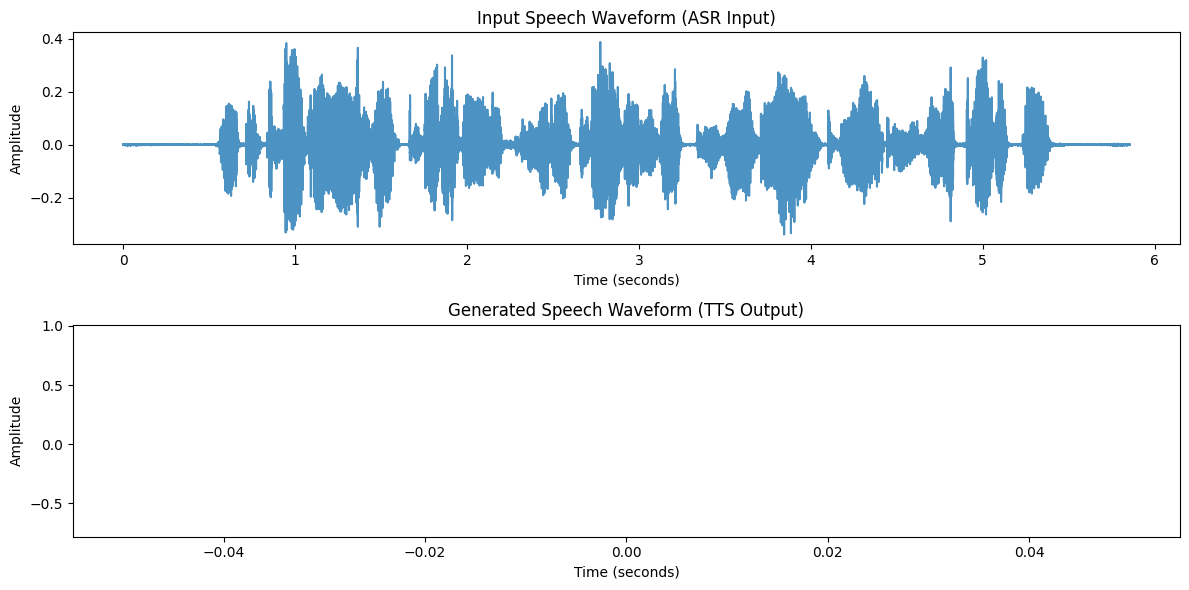

In [11]:
# Step 8 - Plot input and output waveforms

resp_audio = np.array(result["response_audio"], dtype=np.float32)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(np.arange(len(audio_data)) / sr, audio_data, color="tab:blue", alpha=0.8)
axes[0].set_title("Input Speech Waveform (ASR Input)")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(
    np.arange(len(resp_audio)) / result["sample_rate"],
    resp_audio,
    color="tab:green",
    alpha=0.8,
)
axes[1].set_title("Generated Speech Waveform (TTS Output)")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


In [14]:
# Step 8.1 - Record audio from microphone

import sounddevice as sd


def record_from_microphone(duration_sec=5, sample_rate=16000):
    """Record mono float32 audio from the default microphone."""
    print(f"Recording for {duration_sec} seconds... Speak now.")
    recording = sd.rec(
        int(duration_sec * sample_rate),
        samplerate=sample_rate,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    print("Recording complete.")
    return recording[:, 0], sample_rate


# You can adjust duration_sec for classroom demos.
mic_audio, mic_sr = record_from_microphone(duration_sec=5, sample_rate=16000)

print(f"Mic audio length: {len(mic_audio)} samples")
print(f"Mic sample rate: {mic_sr} Hz")

# Optional: play back what was recorded.
display(Audio(mic_audio, rate=mic_sr))


Recording for 5 seconds... Speak now.


KeyboardInterrupt: 

In [13]:
# Step 8.2 - Run assistant on microphone audio

mic_result = assistant.process_audio(mic_audio, mic_sr)

print("\n--- Microphone Pipeline Output ---")
print("Transcription:", mic_result["transcription"])
print("Assistant Response:", mic_result["response_text"])

# Play assistant voice response.
display(Audio(mic_result["response_audio"], rate=mic_result["sample_rate"]))


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



--- Microphone Pipeline Output ---
Transcription: you
Assistant Response: p
